In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:

use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
app_name = "mummi5node" # resnet cosmoflow unet3d mummi deepspeed dlio_resnet dlio_cosmoflow
# app_name = "montage"


condition_fn = None #


if app_name == "mummi5node":
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummI-5_node-dlio-profiler/*.pfw.gz"
    # filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummi5node/mummI-5_node-dlio-profile/output/*.pfw.gz"
    cp_dir = "/p/lustre2/pandey2/cp_dir/mummi"

elif app_name == "montage":
    filename ="/usr/workspace/iopp/graph-io/dlp_logs/montage_16_48ppn/montage*.pfw"

elif app_name == "deepspeed":
    filename = "/usr/workspace/iopp/dlp_traces/deepspeed_8_4ppn/*.pfw.gz"

else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, 
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=False, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [13:14:35] Initialized Client with 192 workers and link http://134.9.71.28:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:673]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [13:14:41] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:665]


2024-09-25 14:25:00,423 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [4]:

def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))


In [5]:
def mummi_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return '/'.join(path.split('/', 3)[:3])
    
    if "args" in json_object:
        # if "hostname" in json_object["args"]:
        #     d["hostpid"] = json_object["args"]["hostname"]+str(json_object["pid"])
            
        if "filename" in json_object["args"]:
            d["filename"] = str(json_object["args"]["filename"])   
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["filename"]))
    return d
load_cols_mummi = {'path':"string[pyarrow]", 'filename':"string[pyarrow]",'mount_point':"string[pyarrow]"}



In [6]:
#Change
analyzer_mummi = DFAnalyzer(filename,load_fn=mummi_cols_function, load_cols=load_cols_mummi, load_data={"mount_point":trie})


[INFO] [13:14:46] Created index for 12 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:371]
[INFO] [13:14:46] Total size of all files are <dask.bag.core.Item object at 0x1555417bb8b0> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:373]
[INFO] [13:14:48] Loading 94 batches out of 12 files and has 1387329 lines overall [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:386]
[INFO] [13:14:54] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:431]
[INFO] [13:14:54] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:437]


In [7]:
x = analyzer_mummi.events.compute()
# x.query('mount_point =="/p/gpfs1" and size > 0')

In [8]:
len(x[x['size'] > 0])

505489

In [7]:
analyzer_mummi.events['id'] = analyzer_mummi.events.index
# 

In [8]:
IFCalculator = DFGrepInterference(analyzer_mummi.events, app_name="mummi5node", cp_dir=cp_dir, existing=False)

In [15]:
IFCalculator.ddf_metadata.compute()

,id,name,pid,size,ts,te,mount_point,dur,trange
0,0,__xstat64,101820,<NA>,25538,25554,/p/gpfs1,16,0
1,1,__xstat64,101820,<NA>,28687,28693,/tmp,6,0
2,2,__xstat64,101820,<NA>,29794,29800,/tmp,6,0
3,3,open64,101820,<NA>,30578,30627,/tmp,49,0
4,4,readlink,101820,<NA>,31444,31453,/tmp,9,0
...,...,...,...,...,...,...,...,...,...
4797,4797,__xstat64,61771,<NA>,6787345612,6787345622,/p/gpfs1,10,226
4798,4798,__xstat64,61771,<NA>,6787346956,6787346966,/p/gpfs1,10,226
4799,4799,__xstat64,61771,<NA>,6787348286,6787348296,/p/gpfs1,10,226
4800,4800,__xstat64,61771,<NA>,6787349612,6787349622,/p/gpfs1,10,226


In [11]:
len(IFCalculator.ddf_data.compute()) + len(IFCalculator.ddf_metadata.compute())

506961

In [13]:
len(x.query('name != "read" and name != "write"'))

880131

In [14]:
880131+506961

1387092

In [10]:
IFCalculator.ddf_data.compute()

,id,name,pid,size,ts,te,mount_point,dur,trange
13,13,write,101820,85,39614,39632,/tmp,18,0
15,15,write,101820,85,41526,41553,/tmp,27,0
17,17,write,101820,88,43475,43487,/tmp,12,0
19,19,write,101820,88,45143,45152,/tmp,9,0
21,21,write,101820,86,46918,46928,/tmp,10,0
...,...,...,...,...,...,...,...,...,...
422,422,write,76673,432,5334050387,5334051793,/p/gpfs1,1406,177
426,426,write,76673,60,5334060009,5334060025,/p/gpfs1,16,177
436,436,write,76673,1860,5334081341,5334081358,/p/gpfs1,17,177
440,440,write,76673,67,5334089838,5334089854,/p/gpfs1,16,177


In [14]:
IFCalculator.ddf_metadata.name.unique().compute()

0    read
Name: name, dtype: string

In [9]:
IFCalculator.get_degree()
IFCalculator.get_interference()

In [12]:
IFCalculator.get_interference_metadata()

In [13]:
IFCalculator.write_checkpoint("inter", cp_dir=cp_dir)
IFCalculator.write_checkpoint("inter_metadata", cp_dir=cp_dir)

In [14]:
IFCalculator.inter.compute()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,write,76673,33854,90070695,90070781,/p/gpfs1,86,3,1,1,74,0.860465
1,read,76673,4520,90419772,90419788,/p/gpfs1,16,3,1,1,16,1.0
2,write,76673,33854,90596332,90596488,/p/gpfs1,156,3,1,1,74,0.474359
3,read,76673,4671,90958443,90958458,/p/gpfs1,15,3,1,1,14,0.933333
4,write,76673,33854,91171109,91171273,/p/gpfs1,164,3,1,1,74,0.45122
...,...,...,...,...,...,...,...,...,...,...,...,...
182937,write,174828,635,6568953974,6568954013,/tmp,39,218,1,1,11,0.282051
182938,write,62692,227,6569616656,6569616693,/tmp,37,218,1,1,10,0.27027
182939,write,62692,227,6569620351,6569620365,/tmp,14,218,1,1,10,0.714286
182940,write,108460,228,6569641641,6569641711,/tmp,70,218,1,1,10,0.142857


In [16]:
IFCalculator.inter_metadata.compute()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,open64,76673,<NA>,90047022,90047468,/p/gpfs1,446,3,1,1,12,0.026906
1,readlink,76673,<NA>,90048791,90048801,/p/gpfs1,10,3,1,1,8,0.8
2,__fxstat64,76673,<NA>,90049929,90049934,/p/gpfs1,5,3,1,1,5,1.0
3,readlink,76673,<NA>,90051122,90051132,/p/gpfs1,10,3,1,1,8,0.8
4,lseek64,76673,<NA>,90052263,90052270,/p/gpfs1,7,3,1,1,6,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...
302735,__xstat64,62692,<NA>,6569622093,6569622100,/tmp,7,218,1,1,5,0.714286
302736,__xstat64,108460,<NA>,6569634880,6569634923,/tmp,43,218,1,1,5,0.116279
302737,readlink,108460,<NA>,6569638491,6569638509,/tmp,18,218,1,1,8,0.444444
302738,readlink,108460,<NA>,6569644570,6569644590,/tmp,20,218,1,1,8,0.4


In [17]:
temp = dd.read_parquet(f"/p/lustre2/pandey2/cp_dir/mummi/mummi5node/mummi5node/inter_metadata*.parquet")

In [23]:
temp.groupby('name')['interference'].mean().compute()

name
__fxstat64    0.787483
__lxstat64    0.751054
__xstat64     0.486944
chdir          0.27578
close         0.489475
fcntl          0.79668
lseek64       0.694132
mkdir         0.555062
mmap          0.349535
mmap64         0.49781
open64        0.347186
opendir       0.762223
read          0.776598
readlink      0.682732
rename        0.682131
rmdir         0.868774
chmod         0.887143
Name: interference, dtype: double[pyarrow]

In [17]:
IFCalculator.write_checkpoint("ddf_deg", cp_dir=cp_dir)

ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    pid: int64
    size: int64
    ts: int64
    te: int64
    mount_point: large_string
    dur: int64
    trange: int64
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    pid: uint64
    size: uint64
    ts: uint64
    te: uint64
    mount_point: large_string
    dur: uint64
    trange: uint16
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [18]:
IFCalculator.inter.head()

FutureCancelledError: ('head-1-5-assign-f1c6a878217431e81c8a6a65cbdaccfb', 0) cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [21]:
rd1.head()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,write,104999,33854,210104368,210104471,/p/gpfs1,103,7.0,1,1,69,0.669903
1,read,104999,8192,211147581,211147595,/p/gpfs1,14,7.0,1,1,8,0.571429
2,read,104999,8192,211147723,211147734,/p/gpfs1,11,7.0,1,1,8,0.727273
3,read,104999,8192,211147819,211147828,/p/gpfs1,9,7.0,1,1,8,0.888889
4,read,104999,1752,211147911,211147919,/p/gpfs1,8,7.0,1,1,8,1.0


In [26]:
r = rd1.compute()
print(r.dur.min(), r.dur.max())
print(r.deg_caller.min(), r.deg_caller.max())
print(r["size"].min(), r["size"].max())

5 571939
1 183
1 617099444


In [29]:
print(r["interference"].min(), r["interference"].max())

9.018526630420779e-05 4.3125


In [49]:
deg_unique_values.sort

<function ndarray.sort>

In [28]:
r[r["size"]==1]

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
824,write,136673,1,1951729186,1951729271,/p/gpfs1,85,65.0,1,1,50,0.588235
874,write,40972,1,1954879660,1954879747,/p/gpfs1,87,65.0,1,1,50,0.574713
887,write,29966,1,1956363135,1956363210,/p/gpfs1,75,65.0,1,1,50,0.666667
903,write,149963,1,1959965858,1959965968,/p/gpfs1,110,65.0,1,1,50,0.454545
951,write,38924,1,1961042689,1961042762,/p/gpfs1,73,65.0,1,1,50,0.684932
...,...,...,...,...,...,...,...,...,...,...,...,...
2462,write,56510,1,2529164624,2529164693,/p/gpfs1,69,84.0,1,1,50,0.724638
2463,write,19679,1,2534946985,2534947087,/p/gpfs1,102,84.0,1,1,50,0.490196
2531,write,3962,1,2545008668,2545008769,/p/gpfs1,101,84.0,1,1,50,0.49505
2893,write,146313,1,2601331938,2601332028,/p/gpfs1,90,86.0,1,1,50,0.555556


In [12]:
dft1,agg_dict,len_deg = dur_of_min_deg(ddf_deg)
inter = calculate_interference(dft1,agg_dict=agg_dict,list_deg=len_deg)
#inter1 = calculate_interference_join(dft1, agg_dict=agg_dict, list_deg=len_deg)

In [13]:
inter.to_parquet('/p/lustre2/pandey2/Intermediatefiles/mummi/if')

In [18]:
inter['interfered'] = (inter['interference'] < 0.5).astype(int)


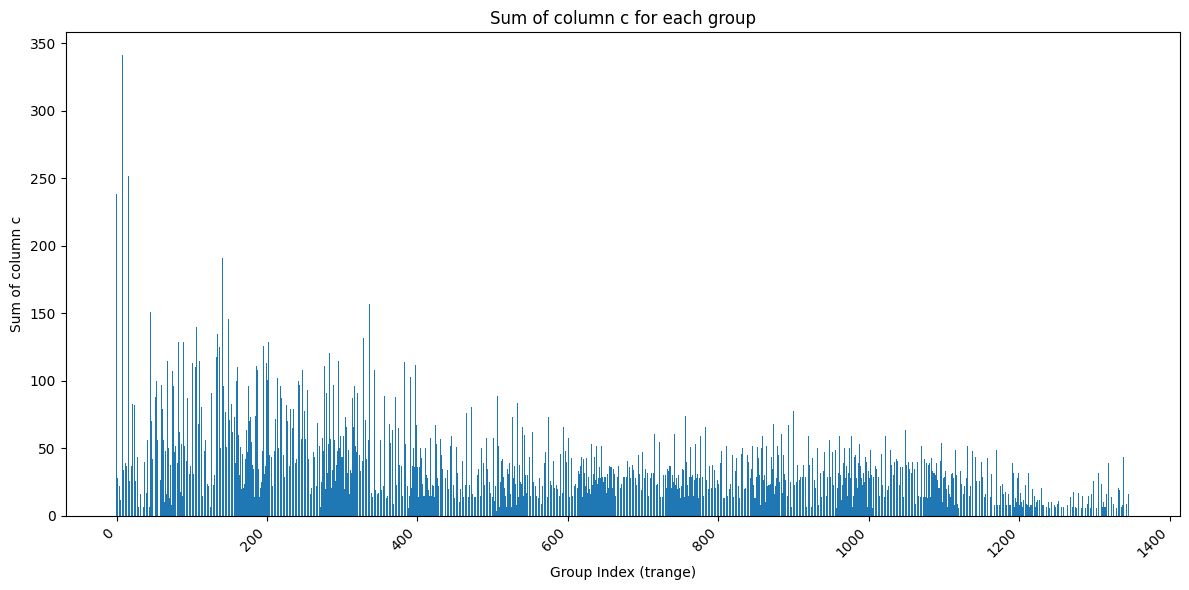

In [19]:
grouped = inter.groupby('trange')['interfered'].sum()
result = grouped.compute()

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(result.index, result.values)
plt.xlabel('Group Index (trange)')
plt.ylabel('Total count of interferred')
plt.title('Sum of column c for each group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

In [25]:
result.sort_values()

trange
56.0        0
80.0        0
57.0        0
1055.0      1
505.0       4
         ... 
141.0     191
23.0      236
0.0       238
16.0      252
8.0       341
Name: interfered, Length: 1287, dtype: int64

In [17]:
inter.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange',
       'deg_caller', 'deg_other', 'min_dur', 'interference'],
      dtype='object')

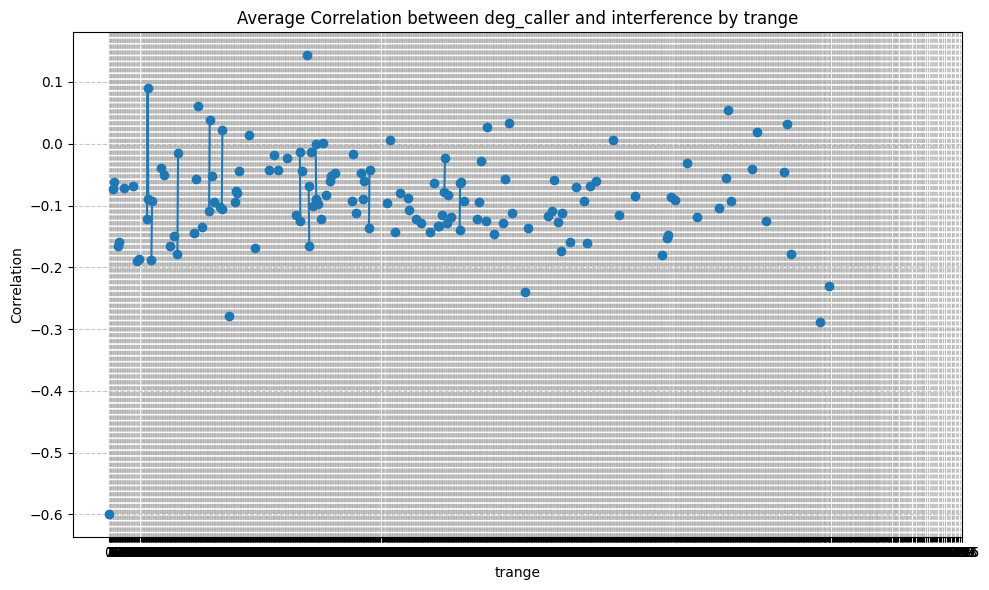

In [18]:
#scatter plot of the intereference, degree, correlation across trange
# Group by 'trange' and compute correlation

grouped = inter.groupby('trange').apply(
    lambda x: x['deg_caller'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()

# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()

# Visualize the results with a line plot
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o')
plt.title('Average Correlation between deg_caller and interference by trange')
plt.xlabel('trange')
plt.ylabel('Correlation')
plt.xticks(grouped.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

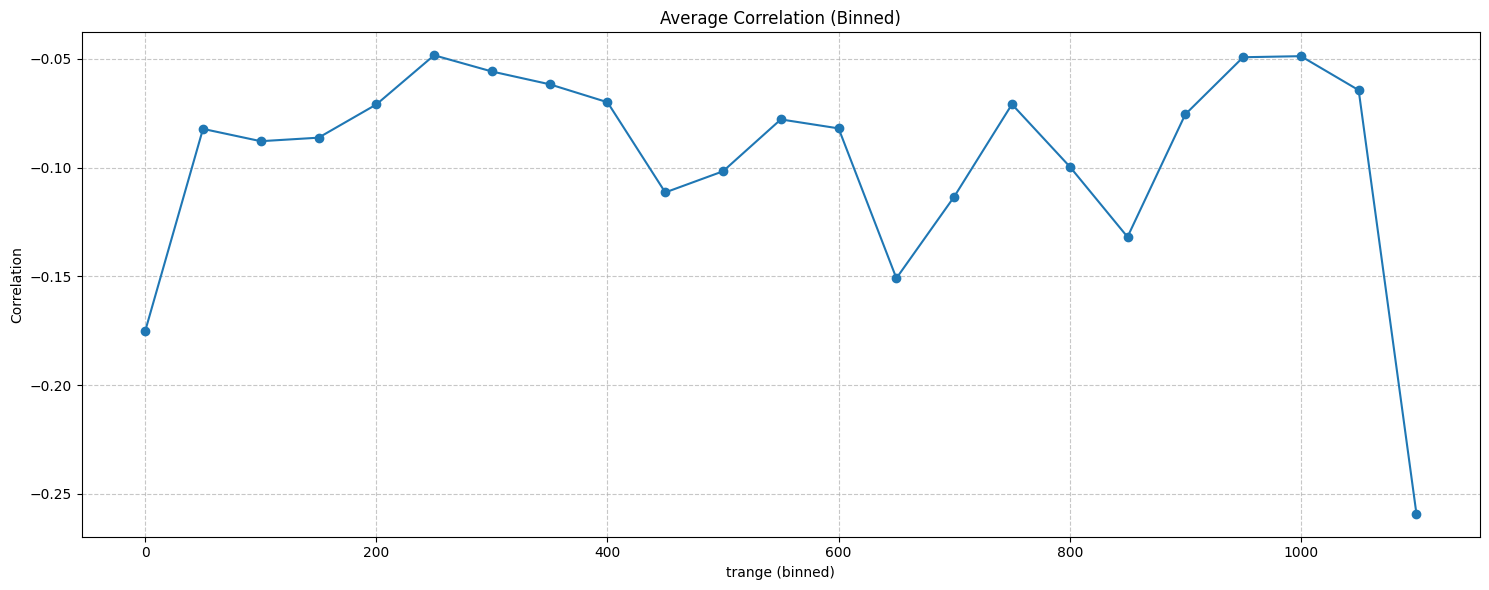

In [20]:
# 1. Binning the trange values
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()

plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('trange (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


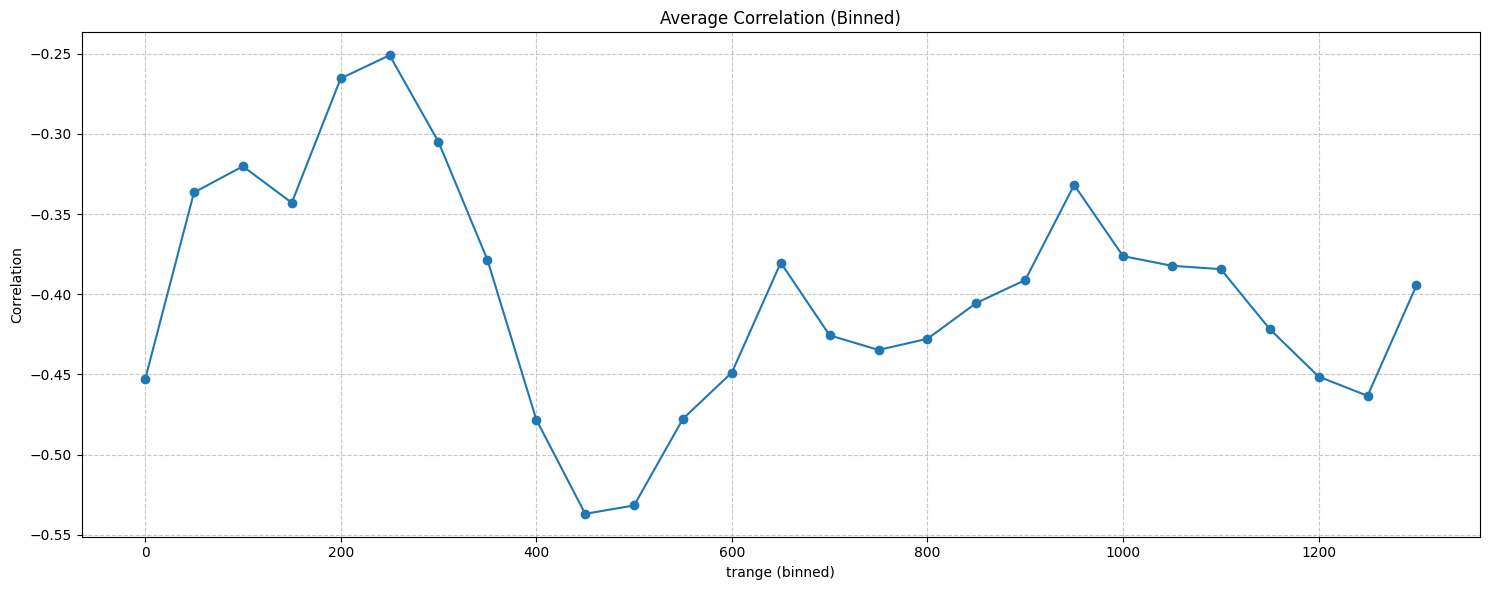

ValueError: cannot reshape array of size 1287 into shape (50)

<Figure size 2000x800 with 0 Axes>

In [21]:
grouped = inter.groupby('trange').apply(
    lambda x: x['dur'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()
# 1. Binning the trange values
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()

plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('trange (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




In [19]:
inter.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange',
       'deg_caller', 'deg_other', 'min_dur', 'interference'],
      dtype='object')

In [24]:

grouped = inter.groupby(['size']).apply(
    lambda x: x['deg_caller'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()
# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()
plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('Size (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


TypeError: cannot perform __floordiv__ with this index type: MultiIndex

In [25]:
grouped.head()

trange  size  mount_point
0.0     22.0  /p/vast1      NaN
        42.0  /p/vast1      NaN
        58.0  /p/gpfs1      NaN
        76.0  /p/gpfs1      NaN
        98.0  /p/vast1      NaN
Name: correlation, dtype: float64

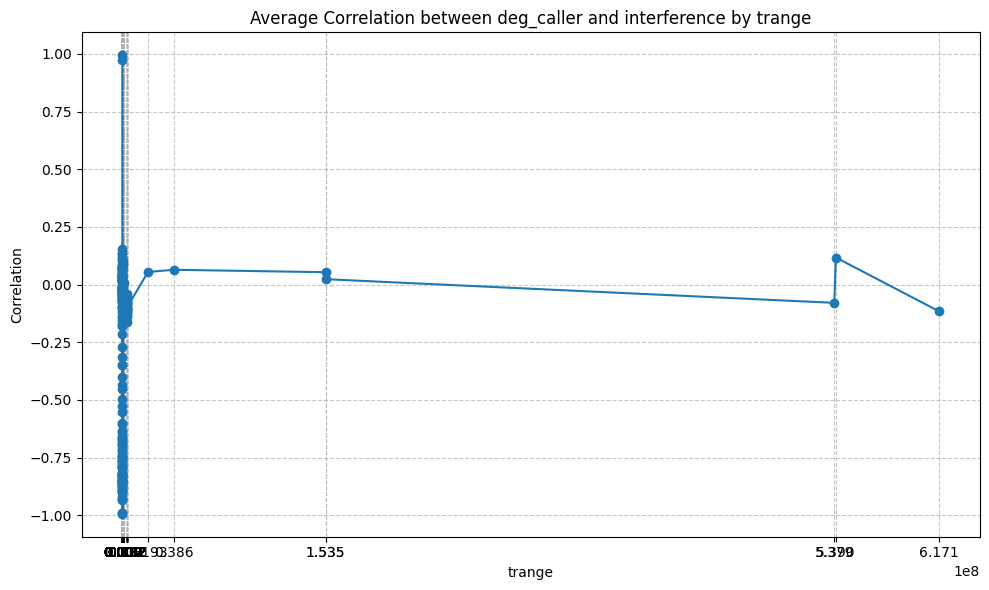

In [22]:
# bin_size = 500  # Adjust this value as needed
# grouped_binned = grouped.groupby(grouped.index // bin_size).mean()
# plt.figure(figsize=(15, 6))
# plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
# plt.title('Average Correlation (Binned)')
# plt.xlabel('Size (binned)')
# plt.ylabel('Correlation')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()

# Visualize the results with a line plot
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o')
plt.title('Average Correlation between deg_caller and interference by trange')
plt.xlabel('trange')
plt.ylabel('Correlation')
plt.xticks(grouped.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
ddf = inter
# Create bins for interference values
bins = [0, 0.25, 0.5, 0.75, 1, float('inf')]
labels = ['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1', '>1']
# Add a new column with binned interference values
ddf['interference_bin'] = ddf['interference'].map_partitions(
    lambda x: pd.cut(x, bins=bins, labels=labels, include_lowest=True)
)
# Compute the counts for each bin
counts = ddf['interference_bin'].value_counts().compute()
# Sample the data for plotting (adjust the fraction as needed)
# sample_df = ddf.sample(frac=0.1).compute()
# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=ddf.compute(), x='trange', y='interference', hue='interference_bin', palette='viridis')
plt.title('Interference vs Trange (Sampled Data)')
plt.xlabel('Trange')
plt.ylabel('Interference')
plt.legend(title='Interference Range')
plt.show()

size   mount_point
60.0   /p/gpfs1      NaN
67.0   /p/gpfs1      NaN
362.0  /p/gpfs1      NaN
390.0  /p/gpfs1      NaN
526.0  /p/gpfs1      NaN
Name: correlation, dtype: float64

In [38]:
def get_edgelist(df):
    edge_list = []
    df = df.sort_values(by='ts').reset_index()
    group_length = len(df)
    for row in range(group_length):
        current_stop_time = df.loc[row,'te']
        for neigh in range(row+1, group_length):
            neigh_start_time = df.loc[neigh,'ts']
            if (neigh_start_time < current_stop_time):
                edge_list.append((row,neigh))
            else:
                break
    return edge_list



In [39]:

temp = get_edgelist(mummiDDf[mummiDDf['trange'] == 8])

ValueError: The truth value of a Series is ambiguous. Use a.any() or a.all().

In [31]:
temp

[]

In [ ]:
import pandas as pd
import numpy as np
import datetime

temp = pd.DataFrame({
    'pid' : [0] * 6,
    'mount_point' : ['alpha', 'beta'] * 3,
    'size' : [1]*6,
    'deg' : [np.random.randint(1,5) for i in range(6)],
    'dur' : [np.random.randint(1,100) for _ in range(6)],
})
tempddf = dd.from_pandas(temp,npartitions=1)
tempddf.compute()

In [ ]:
def dur_of_min_deg1(ddf):
    list_deg = ddf.groupby(["mount_point", "size"])["deg"].min().compute()
    agg_dict = {}
    for deg in list_deg:
        agg_dict[str(deg)] = min
        ddf[str(deg)] = 9223372036854775807
        ddf[str(deg)] = ddf[str(deg)].mask(ddf['deg'] == deg, ddf['dur'])
    return ddf,agg_dict,list_deg

def calculate_interference1(ddf, agg_dict, list_deg):
    agg_dict["deg"]= min
    val = ddf.groupby(['size','mount_point']).agg(agg_dict)
    val['min_dur']= 0
    for deg in list_deg:
        val['min_dur'] = val['min_dur'].mask(val['deg'].eq(deg),val[str(deg)])
    val = val.reset_index()[['name','pid','size', 'ts', 'te', 'mount_point', 'dur', 'trange','deg','min_dur']]
    val['tempIDX'] = val.map_partitions(lambda partition: partition.apply(lambda row: f"{row['size']}/{row['mount_point']}", axis=1), meta=('tempIDX', 'str'))
    # ddf2 = val.reset_index()[['size','mount_point','deg','min_dur']].set_index(['size','mount_point'])
    merge = ddf.join(val, on = ['tempIDX'], validate='m:1', lsuffix='_caller', rsuffix='_other')[['name','pid','size', 'ts', 'te', 'mount_point', 'dur', 'trange','deg','min_dur','deg_caller','deg_other']]
    merge['interference'] = merge['min_dur']/merge['dur']
    return merge

In [61]:
a,b = dur_of_min_deg(tempddf)
a.compute()

,pid,mount_point,size,deg,dur,2,1
0,0,alpha,1,3,76,9223372036854775807,9223372036854775807
1,0,beta,1,4,45,9223372036854775807,9223372036854775807
2,0,alpha,1,4,10,9223372036854775807,9223372036854775807
3,0,beta,1,3,10,9223372036854775807,9223372036854775807
4,0,alpha,1,2,60,60,9223372036854775807
5,0,beta,1,1,53,9223372036854775807,53


In [57]:
a,b = tem(tempddf)
a.compute()

,pid,mount_point,size,deg,dur,1,2
0,0,alpha,1,4,49,999,999
1,0,beta,1,3,74,999,999
2,0,alpha,1,1,32,32,999
3,0,beta,1,2,40,999,40
4,0,alpha,1,2,29,999,29
5,0,beta,1,3,67,999,999


In [63]:
mummiDDf.head()

,name,pid,tid,mount_point,dur,trange,tinterval,hostname,deg
7,read,38924,11634,/p/gpfs1,34394,0.0,"[149387,183781]",lassen429,1
34,write,38924,11634,/p/gpfs1,73,65.0,"[1961169995,1961170068]",lassen429,1
7,read,7935,11634,/p/gpfs1,37576,0.0,"[148545,186121]",lassen262,1
34,write,7935,11634,/p/gpfs1,68,63.0,"[1906224561,1906224629]",lassen262,1
7,read,172837,11634,/p/gpfs1,53939,0.0,"[246933,300872]",lassen278,1


In [ ]:
def dur_of_min_deg(dft):
    # Get the minimum degree for each group
    list_deg = dft.groupby(["mount_point", "size"])["deg"].min().compute()
    agg_dict = {}
    # Create new columns for each unique degree
    for deg in list_deg:
        deg_name = str(deg)
        dft[deg_name] = 9999
        agg_dict[deg_name] = min
        dft[deg_name] = dft.apply(
            lambda row: row["dur"] if row["deg"] == deg else 9999,
            axis=1,
            meta=(deg_name, 'int')
        )
    return dft,agg_dict